Reference trajectory is set


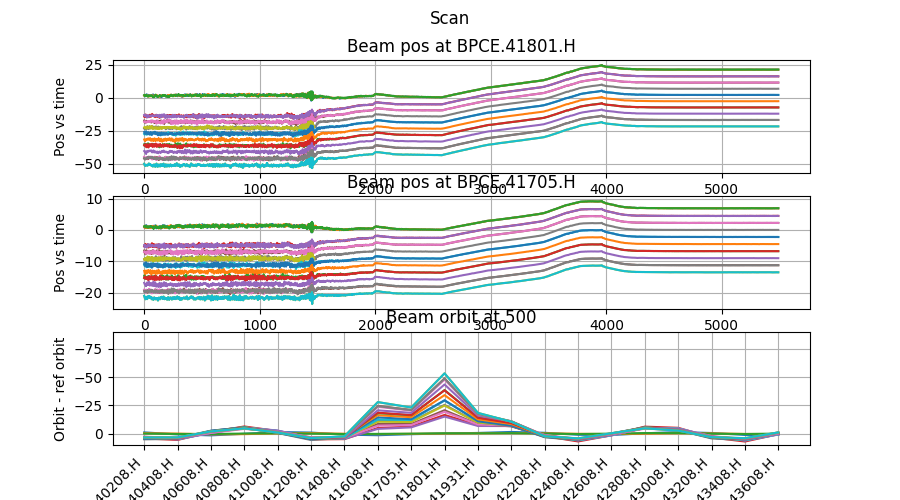

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import functions
import pandas as pd
import numpy as np

# Create figure and axes for the plot
fig_scan, ax_scan = plt.subplots(3, 1, figsize=(9, 5), sharex=False)
fig_scan.suptitle('Scan')  # Use suptitle instead of set_window_title
for ax in ax_scan:
    ax.grid()

df = pd.read_json('scanning-script-fromgit/scan_15_07_2025_19_56.json')


# Create an Experiment instance with minimal required attributes
exp = functions.Experiment(
    japc=None,  # Not needed for plotting
    params_to_get=[],  # Not needed for plotting
    scan_iterable=[],  # Not needed for plotting
    nrep=1,  # Not needed for plotting
    set_address='',  # Not needed for plotting
    fig_scan=fig_scan,
    ax_scan=ax_scan
)


# Plot all entries in df on the same plot
exp.ref_traj = None  # Reset reference trajectory before plotting

for i in range(len(df)):
    exp.data = [{'subscribed parameter': df.iloc[i]['subscribed parameter']}]
    exp.update_plot()

# Update the plot twice - first to set reference, then to plot data
exp.update_plot()  # Sets reference trajectory
#exp.update_plot()  # Plots the data
plt.show()


Reference trajectory is set


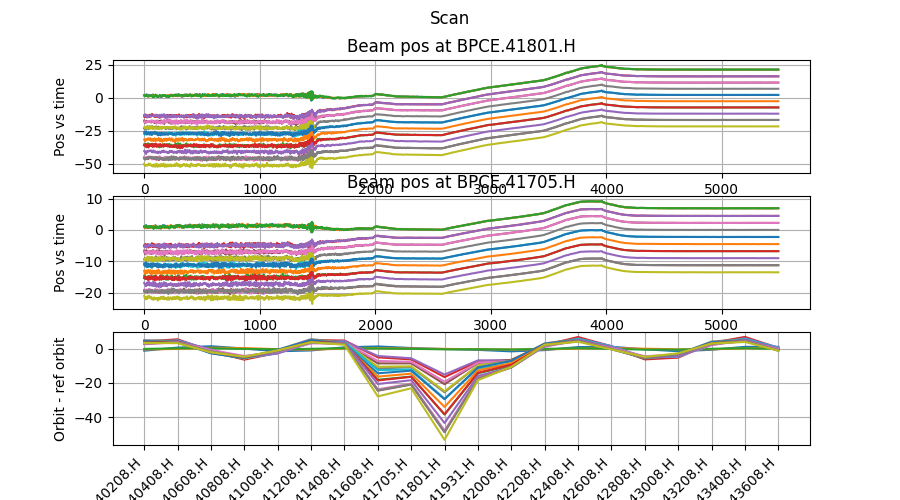

In [2]:
# Create new figure and axes for the plot
fig_scan2, ax_scan = plt.subplots(3, 1, figsize=(9, 5), sharex=False)
fig_scan2.suptitle('Scan')
for ax in ax_scan:
    ax.grid()

# Create a new experiment instance for the second plot
exp2 = functions.Experiment(
    japc=None,
    params_to_get=[],
    scan_iterable=[],
    nrep=1,
    set_address='',
    fig_scan=fig_scan2,
    ax_scan=ax_scan
)

# Plot angles for each data point
for i in range(len(df)):
    exp2.data = [{'subscribed parameter': df.iloc[i]['subscribed parameter']}]
    functions.plot_angles(exp2, time=500)  # Pass exp2 instead of exp.data

plt.show()

# Plotting the beam trajectory for three different times for different bump amplitudes: 500, 3000, 5000 ms

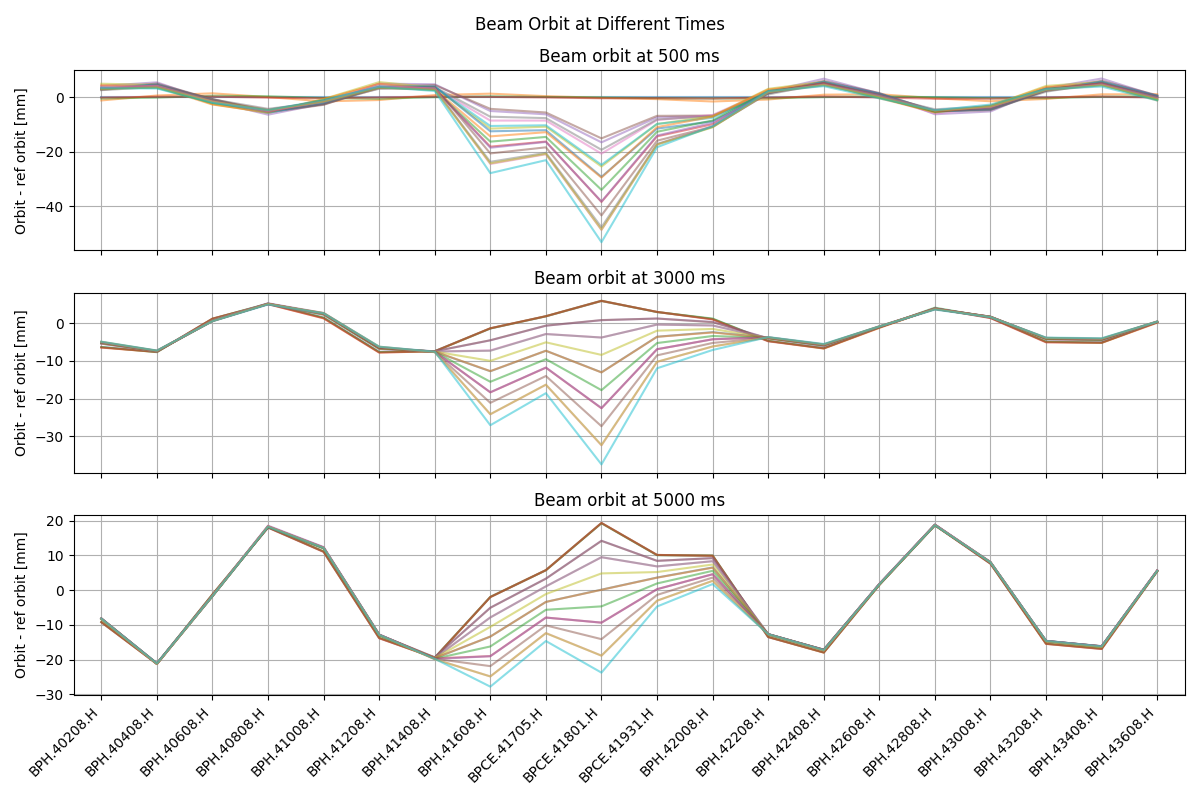

In [3]:
# Create figure and axes for the plot
fig_scan, ax_scan = plt.subplots(3, 1, figsize=(12, 8), sharex=True)  # Fixed figsize
fig_scan.suptitle('Beam Orbit at Different Times')
for ax in ax_scan:
    ax.grid()

# Create an Experiment instance with minimal required attributes
exp = functions.Experiment(
    japc=None,
    params_to_get=[],
    scan_iterable=[],
    nrep=1,
    set_address='',
    fig_scan=fig_scan,
    ax_scan=ax_scan
)

# Define the times we want to plot
times = [500, 3000, 5000]

# Set initial reference trajectory
exp.ref_traj = None
first_data = df.iloc[0]['subscribed parameter']
names = np.array(first_data['channelNames'])
pos = np.array(first_data['positions1'])
hmask = ['.H' in name for name in names]
hnames = names[hmask]
# Replace None with np.nan in reference trajectory
ref_traj_raw = pos[hmask, times[0]]
exp.ref_traj = np.array([x if x is not None else np.nan for x in ref_traj_raw])

# For each knob setting
for i in range(len(df)):
    exp.data = [{'subscribed parameter': df.iloc[i]['subscribed parameter']}]
    data = exp.data[0]['subscribed parameter']
    pos = np.array(data['positions1'])
    
    # For each time point, plot in corresponding subplot
    for idx, time_ms in enumerate(times):
        hmask = ['.H' in name for name in names]
        hnames = names[hmask]
        hpos_raw = pos[hmask, time_ms]
        hpos = np.array([x if x is not None else np.nan for x in hpos_raw])
        hpos = hpos - exp.ref_traj  # Calculate orbit difference
        
        # Plot in the corresponding subplot
        exp.ax_scan[idx].plot(range(len(hnames)), hpos, alpha=0.5)
        
        # Set x-axis limits to avoid blank spaces
        exp.ax_scan[idx].set_xlim(-0.5, len(hnames)-0.5)
        
        
        # Correct way to set x-tick positions and labels
        exp.ax_scan[idx].set_xticks(range(len(hnames)))
        exp.ax_scan[idx].set_xticklabels(hnames, rotation=45, ha='right')
        
        exp.ax_scan[idx].set_ylabel('Orbit - ref orbit [mm]')
        exp.ax_scan[idx].set_title(f"Beam orbit at {time_ms} ms")
        exp.ax_scan[idx].set_title(f"Beam orbit at {time_ms} ms")
        

plt.tight_layout()
plt.show()

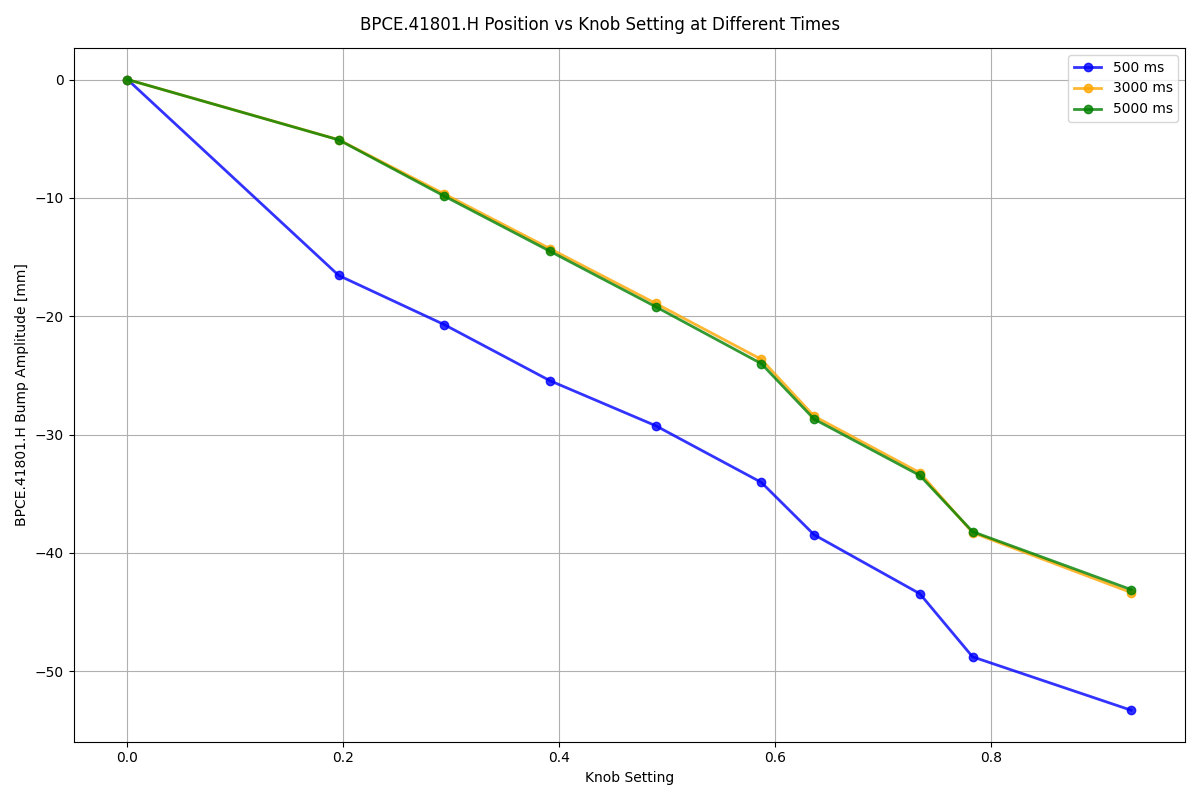

In [4]:
# Create figure and axis for single plot with all times
fig_single, ax_single = plt.subplots(1, 1, figsize=(12, 8))
ax_single.grid()
fig_single.suptitle('BPCE.41801.H Position vs Knob Setting at Different Times')

# Define colors for different times
colors = ['blue', 'orange', 'green']

# Find the index of BPCE.41801.H monitor
monitor_name = 'BPCE.41801.H'
monitor_idx = np.where(names == monitor_name)[0][0]

# Define the times we want to plot
times = [500, 3000, 5000]

# Create normalized x-axis values (knob settings from 0 to 0.93)
knob_settings_normalized = np.linspace(0, 0.93, len(df))

# For each time point, collect positions for all knob settings
for idx, time_ms in enumerate(times):
    positions = []
    knob_values = []
    
    # For each knob setting, get the position at this time
    for i in range(len(df)):
        data = df.iloc[i]['subscribed parameter']
        pos = np.array(data['positions1'])
        
        # Get position at the specific monitor and time
        monitor_pos = pos[monitor_idx, time_ms]
        if monitor_pos is not None:
            # Check if this position differs by at least 3 from the previous one
            if len(positions) > 0 and abs(positions[-1] - monitor_pos) < 3:
                continue  # Skip this iteration if position is too similar
            positions.append(monitor_pos)
            knob_values.append(knob_settings_normalized[i])
        else:
            # Calculate average of previous and next positions for interpolation
            prev_pos = positions[-1] if len(positions) > 0 else None
            
            # Find next valid position
            next_pos = None
            for j in range(i + 1, len(df)):
                next_data = df.iloc[j]['subscribed parameter']
                next_pos_array = np.array(next_data['positions1'])
                next_monitor_pos = next_pos_array[monitor_idx, time_ms]
                if next_monitor_pos is not None:
                    next_pos = next_monitor_pos
                    break
            
            # If we have both previous and next positions, use their average
            if prev_pos is not None and next_pos is not None:
                interpolated_pos = (prev_pos + next_pos) / 2
                # Check if interpolated position differs by at least 3 from previous
                if abs(interpolated_pos - prev_pos) >= 3:
                    positions.append(interpolated_pos)
                    knob_values.append(knob_settings_normalized[i])
            elif prev_pos is not None:
                # Only add if different by at least 3 from previous
                if len(positions) > 1 and abs(prev_pos - positions[-1]) >= 3:
                    positions.append(prev_pos)
                    knob_values.append(knob_settings_normalized[i])
            elif next_pos is not None:
                positions.append(next_pos)
                knob_values.append(knob_settings_normalized[i])
            else:
                positions.append(np.nan)
                knob_values.append(knob_settings_normalized[i])
    
    # Normalize positions by subtracting the first valid position
    if positions and not np.isnan(positions[0]):
        initial_pos = positions[0]
        normalized_positions = [pos - initial_pos for pos in positions]
    else:
        normalized_positions = positions
    
    # Plot normalized positions vs knob settings
    ax_single.plot(knob_values, normalized_positions, 'o-', color=colors[idx], 
                   label=f'{time_ms} ms', alpha=0.8, linewidth=2, markersize=6)

# Set axis labels and formatting
ax_single.set_xlabel('Knob Setting')
ax_single.set_ylabel(f'{monitor_name} Bump Amplitude [mm]')
ax_single.set_xlim(-0.05, 0.98)
ax_single.legend()

plt.tight_layout()
plt.show()


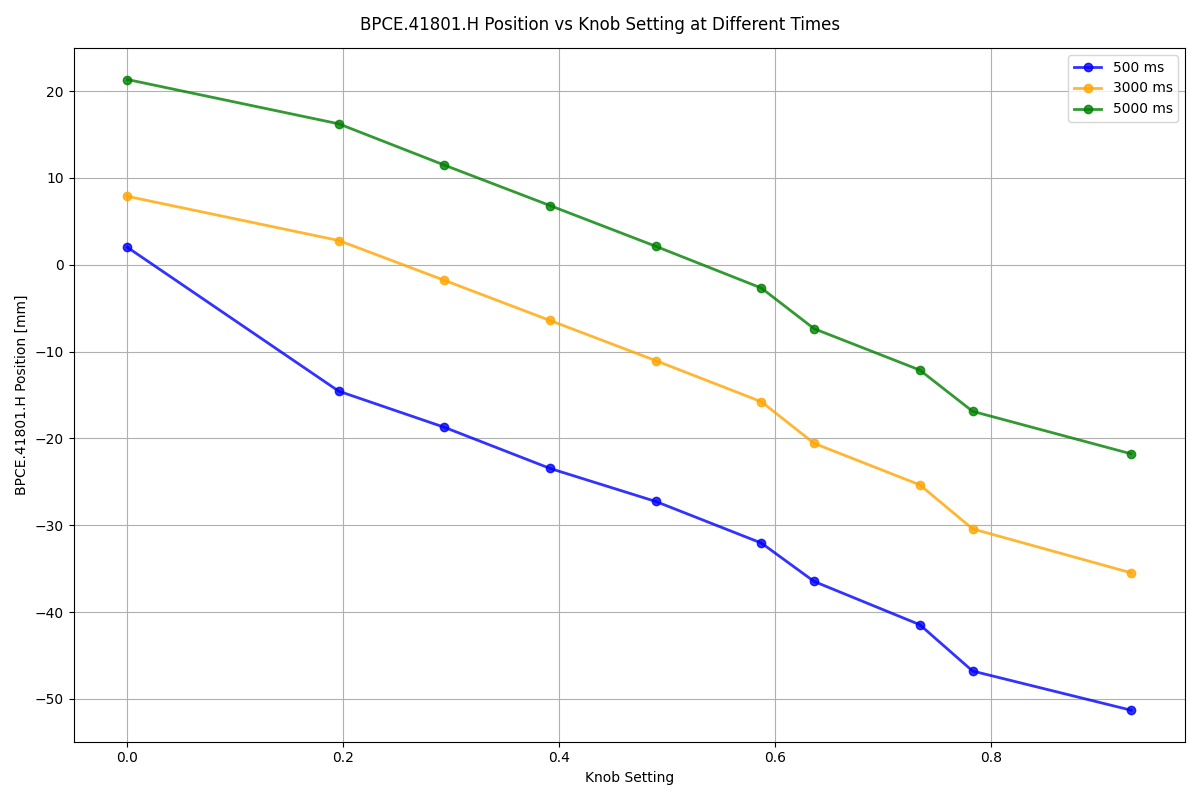

In [5]:
# Create figure and axis for single plot with all times
fig_single, ax_single = plt.subplots(1, 1, figsize=(12, 8))
ax_single.grid()
fig_single.suptitle('BPCE.41801.H Position vs Knob Setting at Different Times')

# Define colors for different times
colors = ['blue', 'orange', 'green']

# Find the index of BPCE.41801.H monitor
monitor_name = 'BPCE.41801.H'
monitor_idx = np.where(names == monitor_name)[0][0]

# Create normalized x-axis values (knob settings from 0 to 0.93)
knob_settings_normalized = np.linspace(0, 0.93, len(df))

# For each time point, collect positions for all knob settings
for idx, time_ms in enumerate(times):
    positions = []
    knob_values = []
    
    # For each knob setting, get the position at this time
    for i in range(len(df)):
        data = df.iloc[i]['subscribed parameter']
        pos = np.array(data['positions1'])
        
        # Get position at the specific monitor and time
        monitor_pos = pos[monitor_idx, time_ms]
        if monitor_pos is not None:
            # Check if this position differs by at least 3 from the previous one
            if len(positions) > 0 and abs(positions[-1] - monitor_pos) < 3:
                continue  # Skip this iteration if position is too similar
            positions.append(monitor_pos)
            knob_values.append(knob_settings_normalized[i])
        else:
            # Calculate average of previous and next positions for interpolation
            prev_pos = positions[-1] if len(positions) > 0 else None
            
            # Find next valid position
            next_pos = None
            for j in range(i + 1, len(df)):
                next_data = df.iloc[j]['subscribed parameter']
                next_pos_array = np.array(next_data['positions1'])
                next_monitor_pos = next_pos_array[monitor_idx, time_ms]
                if next_monitor_pos is not None:
                    next_pos = next_monitor_pos
                    break
            
            # If we have both previous and next positions, use their average
            if prev_pos is not None and next_pos is not None:
                interpolated_pos = (prev_pos + next_pos) / 2
                # Check if interpolated position differs by at least 3 from previous
                if abs(interpolated_pos - prev_pos) >= 3:
                    positions.append(interpolated_pos)
                    knob_values.append(knob_settings_normalized[i])
            elif prev_pos is not None:
                # Only add if different by at least 3 from previous
                if len(positions) > 1 and abs(prev_pos - positions[-1]) >= 3:
                    positions.append(prev_pos)
                    knob_values.append(knob_settings_normalized[i])
            elif next_pos is not None:
                positions.append(next_pos)
                knob_values.append(knob_settings_normalized[i])
            else:
                positions.append(np.nan)
                knob_values.append(knob_settings_normalized[i])
    
    # Plot positions vs knob settings
    ax_single.plot(knob_values, positions, 'o-', color=colors[idx], 
                   label=f'{time_ms} ms', alpha=0.8, linewidth=2, markersize=6)

# Set axis labels and formatting
ax_single.set_xlabel('Knob Setting')
ax_single.set_ylabel(f'{monitor_name} Position [mm]')
ax_single.set_xlim(-0.05, 0.98)
ax_single.legend()

plt.tight_layout()
plt.show()


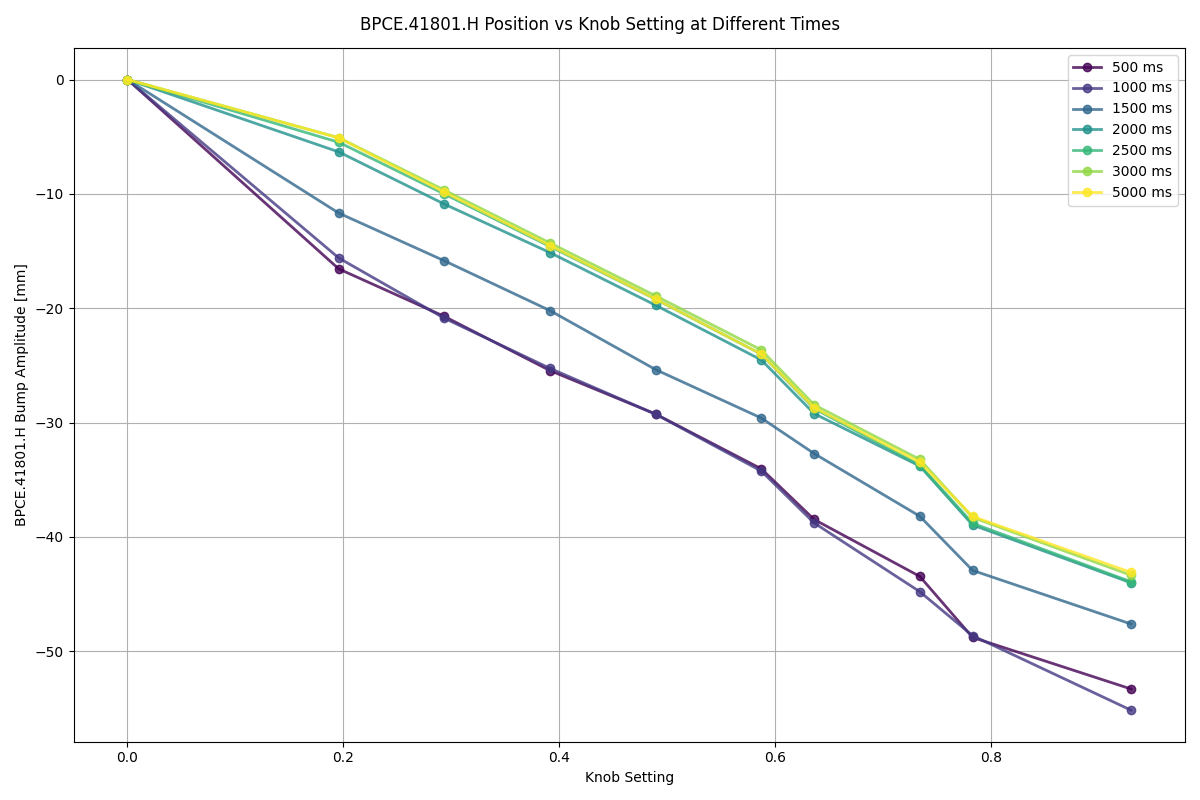

In [6]:
# Create figure and axis for single plot with all times
fig_single, ax_single = plt.subplots(1, 1, figsize=(12, 8))
ax_single.grid()
fig_single.suptitle('BPCE.41801.H Position vs Knob Setting at Different Times')


# Find the index of BPCE.41801.H monitor
monitor_name = 'BPCE.41801.H'
monitor_idx = np.where(names == monitor_name)[0][0]

# Define the times we want to plot
times = [500, 1000, 1500, 2000, 2500, 3000, 5000]


# Define colors for different times
colors = plt.cm.viridis(np.linspace(0, 1, len(times)))

# Create normalized x-axis values (knob settings from 0 to 0.93)
knob_settings_normalized = np.linspace(0, 0.93, len(df))

# For each time point, collect positions for all knob settings
for idx, time_ms in enumerate(times):
    positions = []
    knob_values = []
    
    # For each knob setting, get the position at this time
    for i in range(len(df)):
        data = df.iloc[i]['subscribed parameter']
        pos = np.array(data['positions1'])
        
        # Get position at the specific monitor and time
        monitor_pos = pos[monitor_idx, time_ms]
        if monitor_pos is not None:
            # Check if this position differs by at least 3 from the previous one
            if len(positions) > 0 and abs(positions[-1] - monitor_pos) < 3:
                continue  # Skip this iteration if position is too similar
            positions.append(monitor_pos)
            knob_values.append(knob_settings_normalized[i])
        else:
            # Calculate average of previous and next positions for interpolation
            prev_pos = positions[-1] if len(positions) > 0 else None
            
            # Find next valid position
            next_pos = None
            for j in range(i + 1, len(df)):
                next_data = df.iloc[j]['subscribed parameter']
                next_pos_array = np.array(next_data['positions1'])
                next_monitor_pos = next_pos_array[monitor_idx, time_ms]
                if next_monitor_pos is not None:
                    next_pos = next_monitor_pos
                    break
            
            # If we have both previous and next positions, use their average
            if prev_pos is not None and next_pos is not None:
                interpolated_pos = (prev_pos + next_pos) / 2
                # Check if interpolated position differs by at least 3 from previous
                if abs(interpolated_pos - prev_pos) >= 3:
                    positions.append(interpolated_pos)
                    knob_values.append(knob_settings_normalized[i])
            elif prev_pos is not None:
                # Only add if different by at least 3 from previous
                if len(positions) > 1 and abs(prev_pos - positions[-1]) >= 3:
                    positions.append(prev_pos)
                    knob_values.append(knob_settings_normalized[i])
            elif next_pos is not None:
                positions.append(next_pos)
                knob_values.append(knob_settings_normalized[i])
            else:
                positions.append(np.nan)
                knob_values.append(knob_settings_normalized[i])
    
    # Normalize positions by subtracting the first valid position
    if positions and not np.isnan(positions[0]):
        initial_pos = positions[0]
        normalized_positions = [pos - initial_pos for pos in positions]
    else:
        normalized_positions = positions
    
    # Plot normalized positions vs knob settings
    ax_single.plot(knob_values, normalized_positions, 'o-', color=colors[idx], 
                   label=f'{time_ms} ms', alpha=0.8, linewidth=2, markersize=6)

# Set axis labels and formatting
ax_single.set_xlabel('Knob Setting')
ax_single.set_ylabel(f'{monitor_name} Bump Amplitude [mm]')
ax_single.set_xlim(-0.05, 0.98)
ax_single.legend()

plt.tight_layout()
plt.show()


# Single plot with 0 bump only

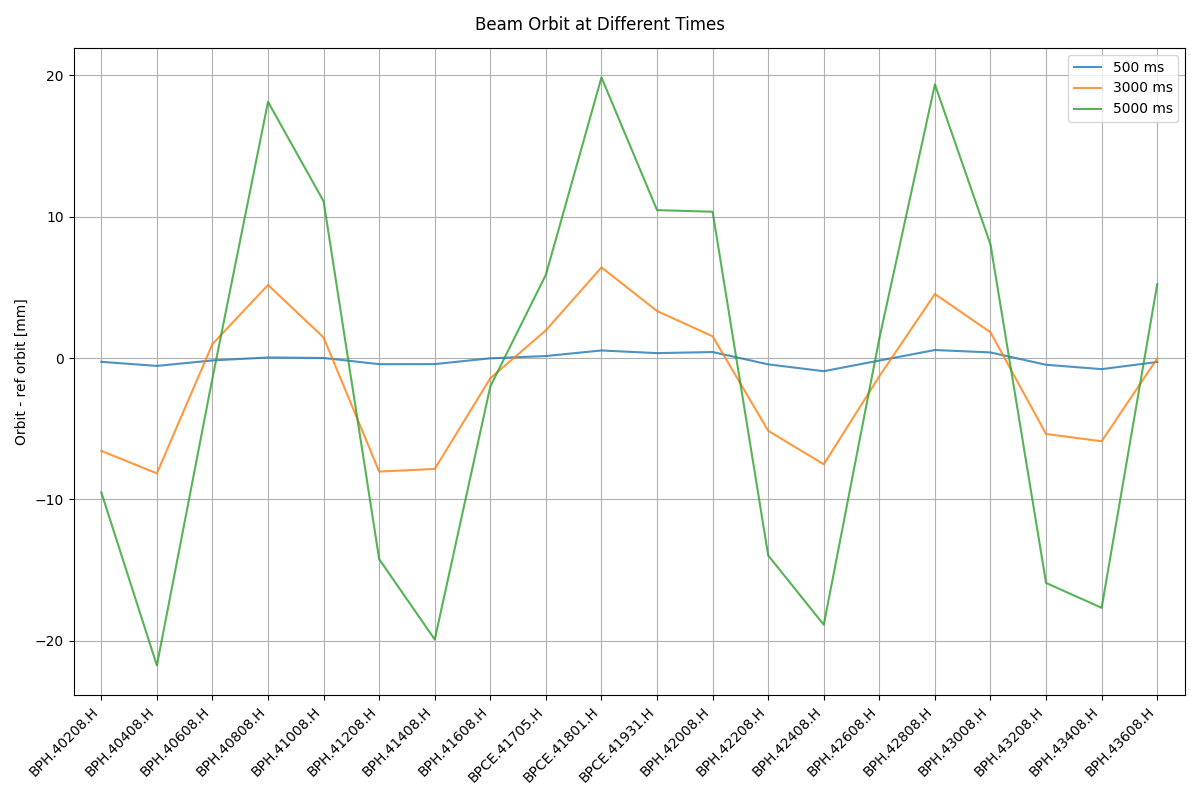

In [7]:
# Create figure and axis for the plot
fig_scan = plt.figure(figsize=(12, 8))
ax_scan = fig_scan.add_subplot(111)  # Single plot
ax_scan.grid()
fig_scan.suptitle('Beam Orbit at Different Times')

# Create an Experiment instance with minimal required attributes
exp = functions.Experiment(
    japc=None,
    params_to_get=[],
    scan_iterable=[],
    nrep=1,
    set_address='',
    fig_scan=fig_scan,
    ax_scan=[ax_scan]  # Pass as list to maintain compatibility
)

# Define the times we want to plot
times = [500, 3000, 5000]

time0 = 0

# Set initial reference trajectory
exp.ref_traj = None
first_data = df.iloc[0]['subscribed parameter']
names = np.array(first_data['channelNames'])
pos = np.array(first_data['positions1'])
hmask = ['.H' in name for name in names]
hnames = names[hmask]
# Replace None with np.nan in reference trajectory
ref_traj_raw = pos[hmask, times[0]]
exp.ref_traj = np.array([x if x is not None else np.nan for x in ref_traj_raw])


# Plot only the first entry (knob=0) at different times
i = 0  # Only use the first entry
exp.data = [{'subscribed parameter': df.iloc[i]['subscribed parameter']}]
data = exp.data[0]['subscribed parameter']
pos = np.array(data['positions1'])

# For each time point, plot with different colors and labels
# First get the orbit at time0
hmask = ['.H' in name for name in names]
hnames = names[hmask]
hpos_raw_t0 = pos[hmask, time0]
hpos_t0 = np.array([x if x is not None else np.nan for x in hpos_raw_t0])

for idx, time_ms in enumerate(times):
    hmask = ['.H' in name for name in names]
    hnames = names[hmask]
    hpos_raw = pos[hmask, time_ms]
    hpos = np.array([x if x is not None else np.nan for x in hpos_raw])
    hpos = hpos - hpos_t0  # Calculate orbit difference from time0
    
    # Plot with different colors and labels
    ax_scan.plot(range(len(hnames)), hpos, alpha=0.8, label=f'{time_ms} ms')

# Set x-axis limits and labels
ax_scan.set_xlim(-0.5, len(hnames)-0.5)
ax_scan.set_xticks(range(len(hnames)))
ax_scan.set_xticklabels(hnames, rotation=45, ha='right')
ax_scan.set_ylabel('Orbit - ref orbit [mm]')
ax_scan.legend()  # Add legend since we removed it from the template
    #ax_scan.legend()

plt.tight_layout()
plt.show()